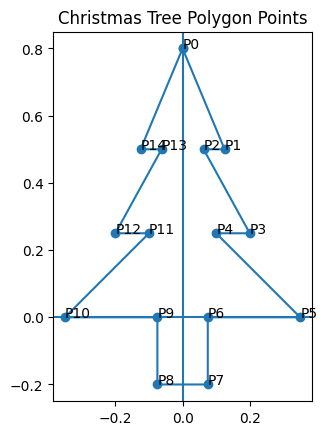

In [ ]:
from decimal import Decimal
import matplotlib.pyplot as plt

# scale factor (same as your code)
scale_factor = Decimal('1')

# parameters
trunk_w = Decimal('0.15')
trunk_h = Decimal('0.2')
base_w = Decimal('0.7')
mid_w = Decimal('0.4')
top_w = Decimal('0.25')

tip_y = Decimal('0.8')
tier_1_y = Decimal('0.5')
tier_2_y = Decimal('0.25')
base_y = Decimal('0.0')

trunk_bottom_y = -trunk_h

# same polygon points as your code
points = [
    (Decimal('0.0') * scale_factor, tip_y * scale_factor),                  # P0
    (top_w / Decimal('2') * scale_factor, tier_1_y * scale_factor),         # P1
    (top_w / Decimal('4') * scale_factor, tier_1_y * scale_factor),         # P2
    (mid_w / Decimal('2') * scale_factor, tier_2_y * scale_factor),         # P3
    (mid_w / Decimal('4') * scale_factor, tier_2_y * scale_factor),         # P4
    (base_w / Decimal('2') * scale_factor, base_y * scale_factor),          # P5
    (trunk_w / Decimal('2') * scale_factor, base_y * scale_factor),         # P6
    (trunk_w / Decimal('2') * scale_factor, trunk_bottom_y * scale_factor), # P7
    (-(trunk_w / Decimal('2')) * scale_factor, trunk_bottom_y * scale_factor), # P8
    (-(trunk_w / Decimal('2')) * scale_factor, base_y * scale_factor),         # P9
    (-(base_w / Decimal('2')) * scale_factor, base_y * scale_factor),          # P10
    (-(mid_w / Decimal('4')) * scale_factor, tier_2_y * scale_factor),         # P11
    (-(mid_w / Decimal('2')) * scale_factor, tier_2_y * scale_factor),         # P12
    (-(top_w / Decimal('4')) * scale_factor, tier_1_y * scale_factor),         # P13
    (-(top_w / Decimal('2')) * scale_factor, tier_1_y * scale_factor),         # P14
]

# convert to floats for matplotlib
xs = [float(p[0]) for p in points] + [float(points[0][0])]
ys = [float(p[1]) for p in points] + [float(points[0][1])]

# draw polygon
plt.figure()
plt.plot(xs, ys, marker='o')

# label points
for i, (x, y) in enumerate(points):
    plt.text(float(x), float(y), f"P{i}", fontsize=10)

# axes
plt.axhline(0)
plt.axvline(0)

plt.title("Christmas Tree Polygon Points")
plt.gca().set_aspect('equal', adjustable='box')

plt.show()

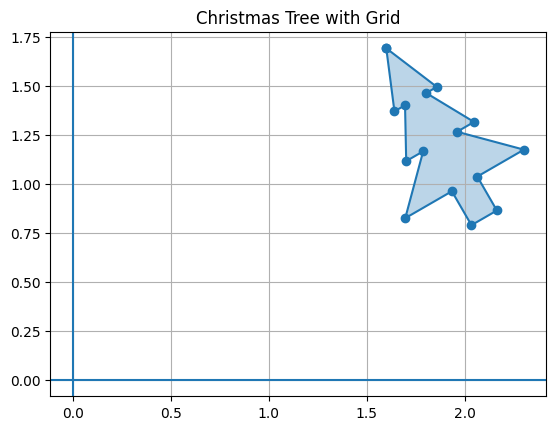

In [15]:
from decimal import Decimal
import matplotlib.pyplot as plt
from shapely.geometry import Polygon
from shapely import affinity

scale_factor = Decimal('1')

class ChristmasTree:

    def __init__(self, center_x='0', center_y='0', angle='0'):

        self.center_x = Decimal(center_x)
        self.center_y = Decimal(center_y)
        self.angle = Decimal(angle)

        trunk_w = Decimal('0.15')
        trunk_h = Decimal('0.2')
        base_w = Decimal('0.7')
        mid_w = Decimal('0.4')
        top_w = Decimal('0.25')

        tip_y = Decimal('0.8')
        tier_1_y = Decimal('0.5')
        tier_2_y = Decimal('0.25')
        base_y = Decimal('0.0')
        trunk_bottom_y = -trunk_h

        initial_polygon = Polygon([
            (0.0, tip_y),
            (top_w/2, tier_1_y),
            (top_w/4, tier_1_y),
            (mid_w/2, tier_2_y),
            (mid_w/4, tier_2_y),
            (base_w/2, base_y),
            (trunk_w/2, base_y),
            (trunk_w/2, trunk_bottom_y),
            (-trunk_w/2, trunk_bottom_y),
            (-trunk_w/2, base_y),
            (-base_w/2, base_y),
            (-mid_w/4, tier_2_y),
            (-mid_w/2, tier_2_y),
            (-top_w/4, tier_1_y),
            (-top_w/2, tier_1_y)
        ])

        rotated = affinity.rotate(initial_polygon, float(self.angle), origin=(0,0))

        self.polygon = affinity.translate(
            rotated,
            xoff=float(self.center_x * scale_factor),
            yoff=float(self.center_y * scale_factor)
        )


tree = ChristmasTree(center_x=2, center_y=1, angle=30)

x, y = tree.polygon.exterior.xy

plt.figure()

# draw tree
plt.plot(x, y, marker='o')
plt.fill(x, y, alpha=0.3)

# draw axis lines
plt.axhline(0)
plt.axvline(0)

# draw grid
plt.grid(True)

# equal scaling
plt.gca().set_aspect('equal', adjustable='box')

plt.title("Christmas Tree with Grid")

plt.show()